# GinzburgLandau JAX API Demo

This is the current serial JAX demo using canonical imports only.

Relevant docs:
- [docs/problems/GinzburgLandau.md](../../docs/problems/GinzburgLandau.md)
- [docs/results/GinzburgLandau.md](../../docs/results/GinzburgLandau.md)


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

REPO_ROOT = Path.cwd()
ARTIFACT_ROOT = Path("artifacts/raw_results/notebook_runs")
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
PYTHON = REPO_ROOT / ".venv" / "bin" / "python"

def dump_json(path):
    with open(path, encoding="utf-8") as handle:
        return json.load(handle)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

from src.core.serial.jax_diff import EnergyDerivator
from src.core.serial.minimizers import newton
from src.core.serial.sparse_solvers import HessSolverGenerator
from src.problems.ginzburg_landau.jax.jax_energy import J
from src.problems.ginzburg_landau.jax.mesh import MeshGL2D

mesh = MeshGL2D(mesh_level=5)
params, adjacency, u_init = mesh.get_data_jax()
energy = EnergyDerivator(J, params, adjacency, u_init)
F, dF, ddF = energy.get_derivatives()
hess_solver = HessSolverGenerator(ddf=ddF, solver_type="amg", verbose=False, tol=1e-3)
result = newton(F, dF, hess_solver, u_init, verbose=False, tolf=1e-6, tolg=1e-5, linesearch_tol=1e-3)
summary = {
    "mesh_level": 5,
    "iterations": int(result["nit"]),
    "energy": float(result["fun"]),
    "message": str(result["message"]),
}
summary


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


{'mesh_level': 5,
 'iterations': 7,
 'energy': 0.34623144378212944,
 'message': 'Stopping condition for f is satisfied'}

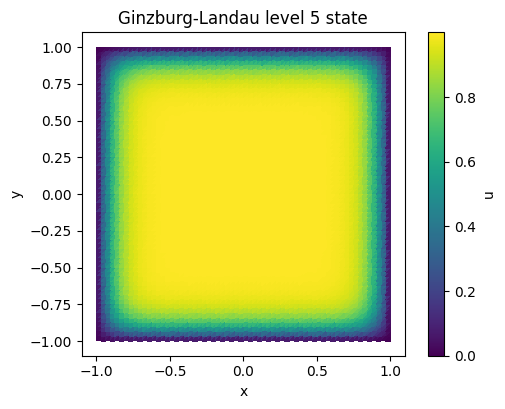

In [3]:
freedofs = np.asarray(params["freedofs"], dtype=np.int64)
u_full = np.asarray(params["u_0"], dtype=np.float64).copy()
u_full[freedofs] = np.asarray(result["x"], dtype=np.float64)
coords = np.asarray(params["nodes"], dtype=np.float64)
triangles = np.asarray(params["elems"], dtype=np.int32)

fig, ax = plt.subplots(figsize=(6.0, 4.2))
tri = Triangulation(coords[:, 0], coords[:, 1], triangles)
artist = ax.tripcolor(tri, u_full, shading="flat", cmap="viridis")
ax.set_aspect("equal")
ax.set_title("Ginzburg-Landau level 5 state")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(artist, ax=ax, label="u")
plt.show()
